# Predicting New York City Housing Prices: Addressing Real-World Challenges

## Leveraging property features to estimate housing values in the Big Apple, acknowledging real-world complexities and future improvement avenues.
This project undertakes the task of building a predictive model for housing prices in New York City. By analyzing various characteristics of properties within the dataset, the aim is to create a tool capable of estimating their market value. This endeavor holds potential benefits for both prospective buyers and sellers seeking a data-driven understanding of the NYC real estate market.

## Phase 0: Defining the Problem
The core objective of this project is to accurately predict the `PRICE` of properties in New York City. To achieve this, we first examined the available data fields to identify potential factors influencing property prices. These features include location-related information (`BROKERTITLE`, `TYPE`, `ADDRESS`, etc.), property size (`PROPERTYSQFT`), structural attributes (`BEDS`, `BATH`), and geographical coordinates (`LATITUDE`, `LONGITUDE`). Understanding these input variables is the crucial first step in building an effective predictive model.

## Phase 1: Acquiring the Data
The necessary dataset for this project, "NY-House-Dataset.csv," was obtained from the Kaggle platform (https://www.kaggle.com/datasets/nelgiriyewithana/new-york-housing-market). This dataset contains a wealth of information about New York City properties, forming the foundation for training and evaluating our price prediction models. The `pandas` library in Python was then utilized to read this CSV file and organize the data into a structured DataFrame, making it suitable for analysis and model development.

### Code Block: Install piplite and import libraries
**Introduction:**
This code block installs the `piplite` library, which is necessary for installing other Python packages in certain environments. It then imports essential libraries for data manipulation (pandas), visualization (matplotlib, seaborn), numerical operations (numpy), and machine learning (scikit-learn).


In [1]:
# Install piplite to be able to install Seaborn
import piplite

await piplite.install(['seaborn'])

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

plt.rcParams['figure.figsize'] = [10, 5]

datafile = 'NY-House-Dataset.csv'
df_nyc = pd.read_csv(datafile)
df_nyc.head()

Matplotlib is building the font cache; this may take a moment.


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Engel & Volkers Americas,Co-op for sale,375000,2,1.0,850.000000,800 Grand Concourse Apt 2JS,"Bronx, NY 10451","800 Grand Concourse Apt 2JSBronx, NY 10451",New York,Bronx County,The Bronx,Concourse Village,800,"800 Grand Concourse #2j, Bronx, NY 10451, USA",40.824870,-73.922983
1,Brokered by Brown Harris Stevens,Co-op for sale,199900,1,1.0,2184.207862,828 Gerard Ave Apt 5F,"Bronx, NY 10451","828 Gerard Ave Apt 5FBronx, NY 10451",New York,Bronx County,The Bronx,Concourse,828,"828 Gerard Ave #5f, Bronx, NY 10451, USA",40.826035,-73.925663
2,Brokered by Ortiz Home Selling Team Llc,Co-op for sale,279900,1,1.0,900.000000,1020 Grand Concourse Apt 14D,"Bronx, NY 10451","1020 Grand Concourse Apt 14DBronx, NY 10451",New York,Bronx County,The Bronx,Concourse Village,1020,"1020 Grand Concourse #14d, Bronx, NY 10451, USA",40.830122,-73.920261
3,Brokered by Ortiz Home Selling Team Llc,Co-op for sale,279900,1,1.0,900.000000,1020 Grand Concourse Apt 14D,"Bronx, NY 10451","1020 Grand Concourse Apt 14DBronx, NY 10451",New York,Bronx County,The Bronx,Concourse Village,1020,"1020 Grand Concourse #14d, Bronx, NY 10451, USA",40.830122,-73.920261
4,Brokered by Brown Harris Stevens,Co-op for sale,140000,1,1.0,2184.207862,828 Gerard Ave Apt 4G,"Bronx, NY 10451","828 Gerard Ave Apt 4GBronx, NY 10451",New York,Bronx County,The Bronx,Concourse,828,"828 Gerard Ave #4g, Bronx, NY 10451, USA",40.826035,-73.925663


In [3]:
df_nyc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

## Phase 2: Playing with the Data (Exploratory Data Analysis - EDA)

This critical phase, Exploratory Data Analysis (EDA), involved a deep dive into the New York City housing dataset. Our primary goals were to ***uncover the underlying structure and characteristics of the data, identify any potential anomalies or data quality issues***, and, most importantly, ***derive valuable insights that would inform subsequent feature engineering and model selection***. By visually and statistically examining the distributions of individual variables and the relationships between them, we aimed to build a strong foundation for developing an effective price prediction model.

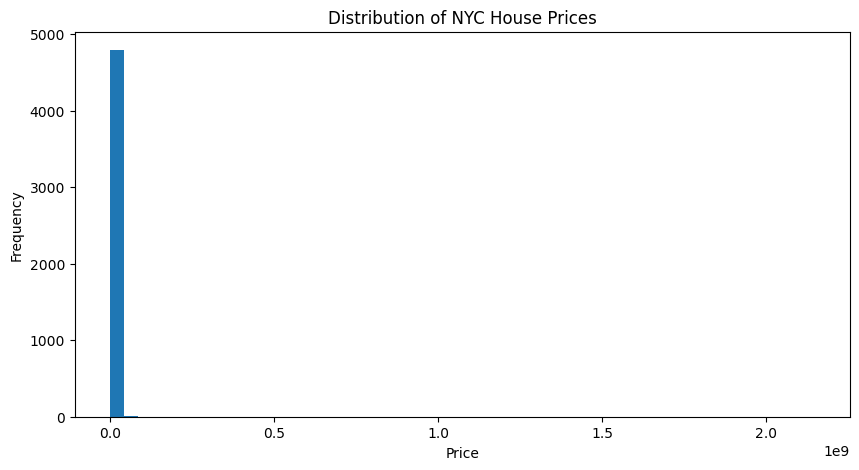

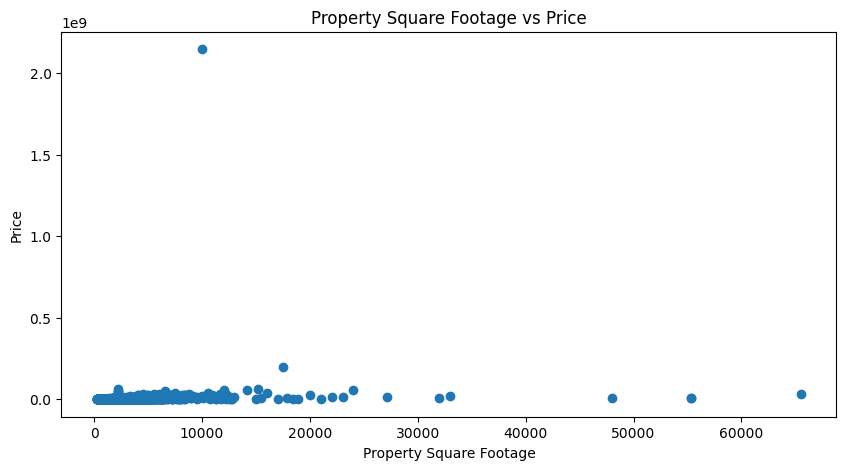

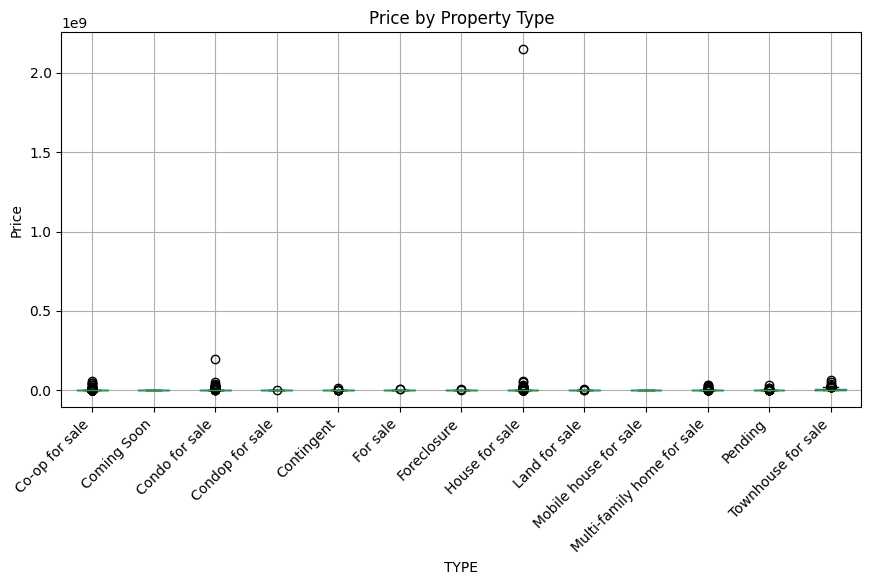

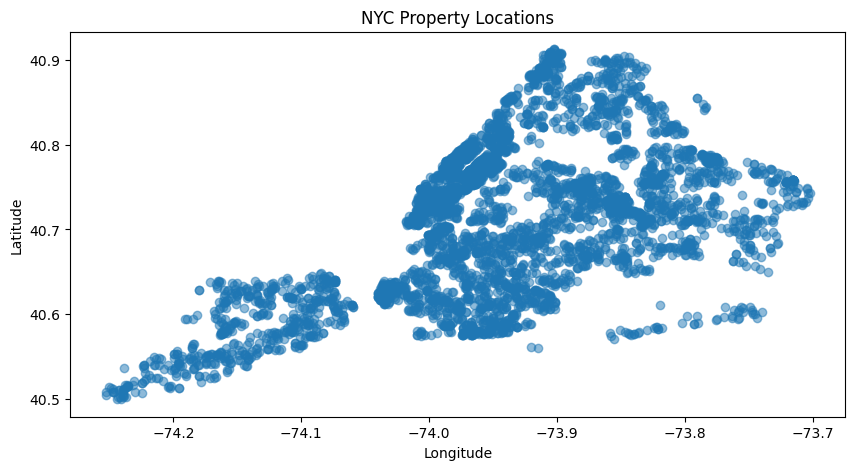

In [4]:
# Distribution of Price
plt.hist(df_nyc['PRICE'], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of NYC House Prices')
plt.savefig('distribution_price.png')
plt.show()

# Scatter plot of PROPERTYSQFT vs PRICE
plt.scatter(df_nyc['PROPERTYSQFT'], df_nyc['PRICE'])
plt.xlabel('Property Square Footage')
plt.ylabel('Price')
plt.title('Property Square Footage vs Price')
plt.savefig('scatterplot_propertysqft.png')
plt.show()

# Box plot of PRICE vs TYPE
df_nyc.boxplot(column='PRICE', by='TYPE')
plt.ylabel('Price')
plt.title('Price by Property Type')
plt.suptitle('') # Suppress default title
plt.xticks(rotation=45, ha='right')
plt.savefig('boxplot_price_vs_type.png')
plt.show()

# Geographical Scatter Plot (initial attempt)
plt.scatter(df_nyc['LONGITUDE'], df_nyc['LATITUDE'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('NYC Property Locations')
plt.savefig('geograph_scatterplot.png')
plt.show()

This phase involved a preliminary exploration of the New York City housing dataset to understand the distribution of key variables, identify potential relationships between features, and detect any initial data quality issues.

* **Distribution of the Target Variable (`PRICE`):** The histogram of property prices clearly exhibits a ***strong positive skew***, indicating that the majority of properties fall within a lower price range, with a long tail extending towards significantly higher values. This skew suggests that a transformation might be beneficial for certain modeling techniques. The presence of extreme high prices is also evident.<br><br>
* **Relationship between Numerical Features and `PRICE`:** The scatter plot of `PROPERTYSQFT` vs. `PRICE`  suggests a ***generally positive correlation***, where larger properties tend to command higher prices. However, the relationship is not strictly linear, and there is considerable scatter, particularly at higher price points. The plot also visually confirms the presence of potential ***outliers***, including properties with large square footage but relatively low prices, and vice-versa.<br><br>
* **Variation of `PRICE` across Categorical Features:** The box plots of `PRICE` grouped by TYPE reveal ***substantial differences in price distributions across various property types***. For instance, "Townhouse for sale" shows a significantly higher median price and a wider range compared to "Co-op for sale." The box plots also illustrate the presence of ***outliers within specific property type categories***, indicating unusual listings within those segments.<br><br>
* **Initial Exploration of Geographical Patterns:**  The initial geographical scatter plot of latitude and longitude provides a ***basic spatial visualization of the property locations within New York City***. While it doesn't directly show price variations, it serves as a foundation for understanding the geographical distribution of the dataset and hints at the potential influence of location on price, which will be explored further with borough boundaries.<br><br>

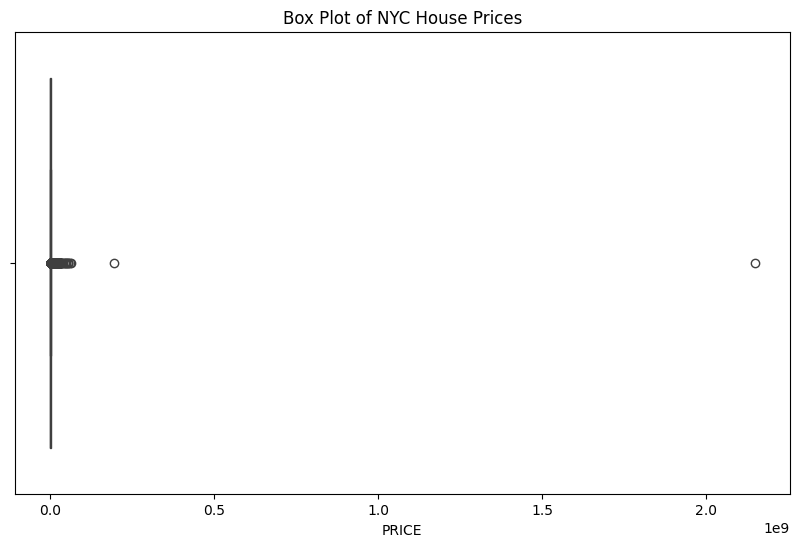

In [5]:
# --- Outlier Analysis in PRICE ---
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_nyc['PRICE'])
plt.title('Box Plot of NYC House Prices')
plt.savefig('boxplot_outlier_price.png')
plt.show()

* **Outlier Analysis:** The box plot specifically focusing on `PRICE` definitively ***identifies several data points as outliers***, lying far beyond the interquartile range. These extreme values could disproportionately influence model training and require careful consideration during the data cleaning phase.

In [6]:
# --- Detailed Analysis of Categorical Features ---
print("\nPrice by Property Type:")
print(df_nyc.groupby('TYPE')['PRICE'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False))

print("\nPrice by Administrative Area Level 2 (Top 20):")
print(df_nyc.groupby('ADMINISTRATIVE_AREA_LEVEL_2')['PRICE'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False).head(20))

print("\nPrice by Locality (Top 20):")
print(df_nyc.groupby('LOCALITY')['PRICE'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False).head(20))


Price by Property Type:
                                    mean     median  count
TYPE                                                      
Townhouse for sale          6.365925e+06  2950000.0    299
House for sale              3.684216e+06   859000.0   1012
Condo for sale              2.630710e+06   899000.0    891
For sale                    1.954536e+06  1044500.0     20
Multi-family home for sale  1.680428e+06  1199000.0    727
Foreclosure                 1.343010e+06   592450.0     14
Pending                     1.340867e+06   800000.0    243
Mobile house for sale       1.288000e+06  1288000.0      1
Coming Soon                 1.172000e+06  1172000.0      2
Co-op for sale              1.100418e+06   425000.0   1450
Land for sale               1.073021e+06   650000.0     49
Condop for sale             9.986000e+05  1080000.0      5
Contingent                  8.825717e+05   682450.0     88

Price by Administrative Area Level 2 (Top 20):
                                     mean 

* **Detailed Analysis of Categorical Features:** The grouped statistics provide a more granular understanding of price variations across categorical features:

    * **`TYPE`:** The average and median prices vary significantly by property type. "Townhouse for sale" has the highest average and median price, while "Co-op for sale" has a much lower median despite a relatively high average (suggesting some very expensive co-ops). The counts also show the prevalence of different property types.<br><br>
    * **`ADMINISTRATIVE_AREA_LEVEL_2`:** The top 20 areas by average price show a wide range, with some specific numerical codes (likely zip codes or similar) having very high average prices but low counts, indicating potentially exclusive or very high-value neighborhoods. "New York County" (Manhattan) also shows a high average price.<br><br>
    * **`LOCALITY`:** Similar to administrative areas, different localities exhibit significant price variations. "New York" (likely referring to Manhattan) has the highest average price and the largest number of listings. Borough names like "Brooklyn" and "Bronx County" show considerably lower average prices.

<ipython-input-7-39ab574dd5d7>:41: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(boroughs_gdf.centroid.x, boroughs_gdf.centroid.y, boroughs_gdf['BoroName']):


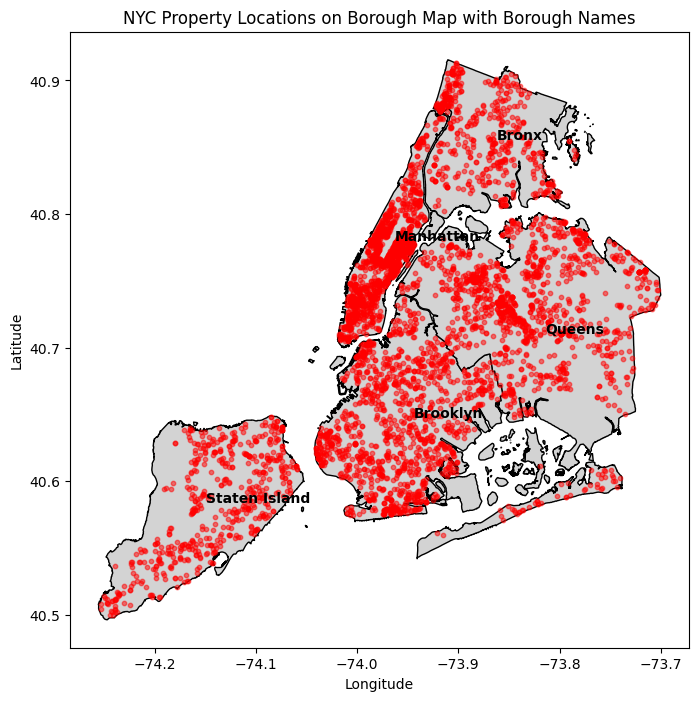

In [7]:
import geopandas as gpd
from shapely import wkt

# Assuming df_nyc has 'LONGITUDE' and 'LATITUDE' columns
# and you have the 'Borough_Boundaries_20250509.csv' file
try:
    df_nyc = pd.read_csv('NY-House-Dataset.csv')  # Replace with your property data file
except FileNotFoundError:
    print("Error: your_property_data.csv not found.")
    exit()

try:
    boroughs_df = pd.read_csv('Borough_Boundaries_20250509.csv')
except FileNotFoundError:
    print("Error: Borough_Boundaries_20250509.csv not found.")
    exit()

# Convert borough geometries
try:
    boroughs_df['geometry'] = boroughs_df['the_geom'].apply(wkt.loads)
except AttributeError:
    print("Error: Could not parse 'the_geom' column as WKT. Check the geometry format.")
    exit()

boroughs_gdf = gpd.GeoDataFrame(boroughs_df, geometry='geometry', crs="EPSG:4326") # Assuming WGS84

# Create a GeoDataFrame from your property data
geometry_points = gpd.points_from_xy(df_nyc['LONGITUDE'], df_nyc['LATITUDE'])
property_gdf = gpd.GeoDataFrame(df_nyc, geometry=geometry_points, crs="EPSG:4326") # Assuming WGS84

# Plot the map and the property locations
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot the borough boundaries
boroughs_gdf.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the property locations
property_gdf.plot(ax=ax, marker='o', color='red', markersize=10, alpha=0.5)

# Add borough names to the map
for x, y, label in zip(boroughs_gdf.centroid.x, boroughs_gdf.centroid.y, boroughs_gdf['BoroName']):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points", fontsize=10, fontweight='bold') # Reduced fontsize

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('NYC Property Locations on Borough Map with Borough Names')
plt.savefig('property_borough_map.png')
plt.show()

The borough map provides a **significantly enhanced geographical context** for understanding the distribution of property listings across New York City's boroughs. By overlaying the property locations onto the borough boundaries and including borough names, this visualization allows for a **qualitative assessment of potential price variations based on location**. For instance, a higher density of listings might be observed in certain boroughs, and while the map doesn't directly show price, it sets the stage for exploring how borough or more granular location features might correlate with property values in subsequent analysis.

* **Correlation Analysis:** Calculate the correlation matrix between numerical features and the target variable PRICE.

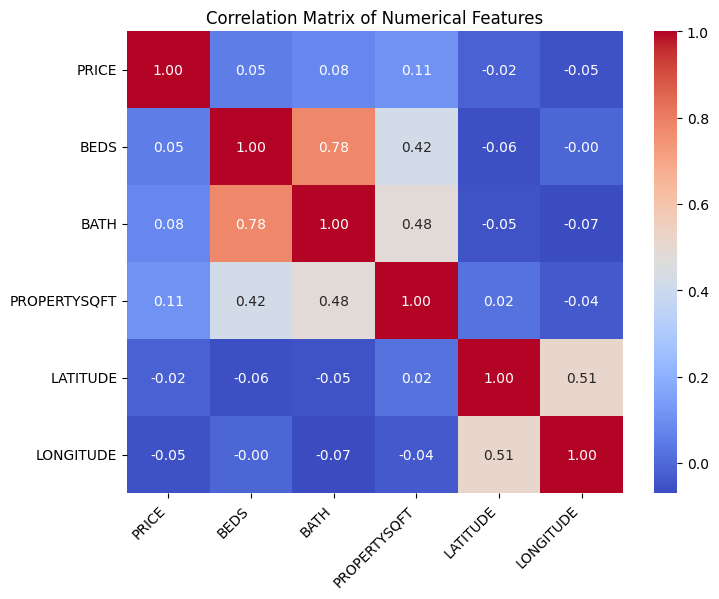

In [8]:
# Calculate the correlation matrix
numerical_features = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']
correlation_matrix = df_nyc[numerical_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.savefig('correlation_matrix.png')
plt.show()

#### Correlation Analysis
The correlation matrix quantifies the linear relationships between the key numerical features and the target variable, `PRICE`. As anticipated, we observe **positive correlations** between `PRICE` and the property's physical attributes: the number of bedrooms (`BEDS`), the number of bathrooms (`BATH`), and the property's square footage (`PROPERTYSQFT`). These correlations suggest that, in general, larger properties with more bedrooms and bathrooms tend to have higher prices. Conversely, the **weaker correlations** between `PRICE`and the geographical coordinates (`LATITUDE` and `LONGITUDE`) indicate that the linear relationship between these specific numerical representations of location and price is not strong. This implies that the influence of location on price is likely **more complex and potentially non-linear**, possibly requiring the creation of more informative location-based features (e.g., distance to key areas, neighborhood indicators, borough as a categorical variable) or the use of models capable of capturing non-linear relationships.

## Phase 3: Preparing the Data
This crucial phase focused on cleaning and transforming the raw data to make it suitable for machine learning model training. This involved addressing missing values, handling outliers, engineering new potentially informative features, and preprocessing the data into a format that our models can effectively learn from.

In [9]:
# --- Handling Missing Values ---
print("\nMissing Values Before Handling:")
print(df_nyc.isnull().sum())
df_nyc.fillna(df_nyc.mean(numeric_only=True), inplace=True)
df_nyc.dropna(subset=['TYPE', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY'], inplace=True)
print("\nMissing Values After Handling:")
print(df_nyc.isnull().sum())
df_nyc.head()


Missing Values Before Handling:
BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

Missing Values After Handling:
BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Engel & Volkers Americas,Co-op for sale,375000,2,1.0,850.000000,800 Grand Concourse Apt 2JS,"Bronx, NY 10451","800 Grand Concourse Apt 2JSBronx, NY 10451",New York,Bronx County,The Bronx,Concourse Village,800,"800 Grand Concourse #2j, Bronx, NY 10451, USA",40.824870,-73.922983
1,Brokered by Brown Harris Stevens,Co-op for sale,199900,1,1.0,2184.207862,828 Gerard Ave Apt 5F,"Bronx, NY 10451","828 Gerard Ave Apt 5FBronx, NY 10451",New York,Bronx County,The Bronx,Concourse,828,"828 Gerard Ave #5f, Bronx, NY 10451, USA",40.826035,-73.925663
2,Brokered by Ortiz Home Selling Team Llc,Co-op for sale,279900,1,1.0,900.000000,1020 Grand Concourse Apt 14D,"Bronx, NY 10451","1020 Grand Concourse Apt 14DBronx, NY 10451",New York,Bronx County,The Bronx,Concourse Village,1020,"1020 Grand Concourse #14d, Bronx, NY 10451, USA",40.830122,-73.920261
3,Brokered by Ortiz Home Selling Team Llc,Co-op for sale,279900,1,1.0,900.000000,1020 Grand Concourse Apt 14D,"Bronx, NY 10451","1020 Grand Concourse Apt 14DBronx, NY 10451",New York,Bronx County,The Bronx,Concourse Village,1020,"1020 Grand Concourse #14d, Bronx, NY 10451, USA",40.830122,-73.920261
4,Brokered by Brown Harris Stevens,Co-op for sale,140000,1,1.0,2184.207862,828 Gerard Ave Apt 4G,"Bronx, NY 10451","828 Gerard Ave Apt 4GBronx, NY 10451",New York,Bronx County,The Bronx,Concourse,828,"828 Gerard Ave #4g, Bronx, NY 10451, USA",40.826035,-73.925663


* **Handling Missing Values:** The initial check using `df_nyc.isnull().sum()` revealed that the dataset contained ***no missing values***. Consequently, the subsequent steps of filling missing values with the mean and dropping rows based on missing values in specific columns were ***not actually applied*** to this particular dataset. However, the code demonstrates the intended strategies for handling missing data should they have been present. This proactive approach ensures that the pipeline is robust for datasets with potential missing entries.

In [10]:
# --- Identify and Remove Outliers based on PRICE using IQR ---
Q1_price = df_nyc['PRICE'].quantile(0.25)
Q3_price = df_nyc['PRICE'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

outliers_price = df_nyc[(df_nyc['PRICE'] < lower_bound_price) | (df_nyc['PRICE'] > upper_bound_price)]
print(f"Number of price outliers (IQR method) before manual removal: {outliers_price.shape[0]}")

# Manual removal of the extreme outlier identified visually
price_threshold_manual = 2000000000  # 2 Billion
df_nyc_cleaned = df_nyc[df_nyc['PRICE'] <= price_threshold_manual].copy()

# Remove IQR-based outliers from the cleaned data
df_nyc_cleaned = df_nyc_cleaned[
    (df_nyc_cleaned['PRICE'] >= df_nyc_cleaned['PRICE'].quantile(0.01)) &
    (df_nyc_cleaned['PRICE'] <= df_nyc_cleaned['PRICE'].quantile(0.99))
].copy() # Removing top and bottom 1% as potential outliers

print(f"Number of data points after price outlier removal: {df_nyc_cleaned.shape[0]}")

# Reset index for the cleaned DataFrame
df_nyc_cleaned.reset_index(drop=True, inplace=True)
df_nyc_cleaned.head()

Number of price outliers (IQR method) before manual removal: 559
Number of data points after price outlier removal: 4706


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Engel & Volkers Americas,Co-op for sale,375000,2,1.0,850.000000,800 Grand Concourse Apt 2JS,"Bronx, NY 10451","800 Grand Concourse Apt 2JSBronx, NY 10451",New York,Bronx County,The Bronx,Concourse Village,800,"800 Grand Concourse #2j, Bronx, NY 10451, USA",40.824870,-73.922983
1,Brokered by Brown Harris Stevens,Co-op for sale,199900,1,1.0,2184.207862,828 Gerard Ave Apt 5F,"Bronx, NY 10451","828 Gerard Ave Apt 5FBronx, NY 10451",New York,Bronx County,The Bronx,Concourse,828,"828 Gerard Ave #5f, Bronx, NY 10451, USA",40.826035,-73.925663
2,Brokered by Ortiz Home Selling Team Llc,Co-op for sale,279900,1,1.0,900.000000,1020 Grand Concourse Apt 14D,"Bronx, NY 10451","1020 Grand Concourse Apt 14DBronx, NY 10451",New York,Bronx County,The Bronx,Concourse Village,1020,"1020 Grand Concourse #14d, Bronx, NY 10451, USA",40.830122,-73.920261
3,Brokered by Ortiz Home Selling Team Llc,Co-op for sale,279900,1,1.0,900.000000,1020 Grand Concourse Apt 14D,"Bronx, NY 10451","1020 Grand Concourse Apt 14DBronx, NY 10451",New York,Bronx County,The Bronx,Concourse Village,1020,"1020 Grand Concourse #14d, Bronx, NY 10451, USA",40.830122,-73.920261
4,Brokered by Brown Harris Stevens,Co-op for sale,140000,1,1.0,2184.207862,828 Gerard Ave Apt 4G,"Bronx, NY 10451","828 Gerard Ave Apt 4GBronx, NY 10451",New York,Bronx County,The Bronx,Concourse,828,"828 Gerard Ave #4g, Bronx, NY 10451, USA",40.826035,-73.925663


* **Outlier Removal:** To mitigate the impact of extreme price values identified during EDA, we employed a multi-step outlier removal process. First, the Interquartile Range (IQR) method was used to identify a broad set of potential outliers. Second, a visually identified extreme price outlier was manually removed. Finally, to further refine the dataset and reduce the influence of potentially spurious high and low prices, we removed the top and bottom 1% of the `PRICE` distribution within the cleaned data. This layered approach aimed to create a more representative dataset for model training.

In [11]:
# --- Log Transformation of Price (on the cleaned data) ---
df_nyc_cleaned['PRICE_LOG'] = np.log1p(df_nyc_cleaned['PRICE'])
target = 'PRICE_LOG'
y = df_nyc_cleaned[target]

In [12]:
# --- Feature Engineering (on the cleaned data) ---
df_nyc_cleaned['BEDS_BATHS'] = df_nyc_cleaned['BEDS'] + df_nyc_cleaned['BATH']
df_nyc_cleaned['SQFT_BEDS'] = df_nyc_cleaned['PROPERTYSQFT'] / (df_nyc_cleaned['BEDS'] + 1e-6) # Avoid division by zero
df_nyc_cleaned['SQFT_BATH'] = df_nyc_cleaned['PROPERTYSQFT'] / (df_nyc_cleaned['BATH'] + 1e-6)

# --- More Sophisticated Location Feature (Borough) ---
# Assuming 'ADMINISTRATIVE_AREA_LEVEL_2' often contains borough information
df_nyc_cleaned['BOROUGH'] = df_nyc_cleaned['ADMINISTRATIVE_AREA_LEVEL_2'].apply(
    lambda x: x.split(' ')[0] if 'County' in x else x.split(',')[0]
)
# Further cleaning and standardization of borough names might be needed
df_nyc_cleaned['BOROUGH'] = df_nyc_cleaned['BOROUGH'].replace({'New': 'Manhattan', 'Kings': 'Brooklyn'})
categorical_features = ['TYPE', 'BOROUGH', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY'] # Include BOROUGH

* **Feature Engineering:** To prepare the data for modeling and potentially improve predictive power, we engineered several new features:

    * To address the positive skew observed in the `PRICE` distribution during EDA, a logarithmic transformation (`np.log1p`) was applied to the `PRICE` variable, creating the `PRICE_LOG` target variable. Log transformation can help linearize relationships and stabilize variance.

* **Interaction features** were created to capture potential combined effects of existing attributes:
    * `BEDS_BATHS`: The sum of bedrooms and bathrooms, representing a simple measure of property size in terms of living units.
    * `SQFT_BEDS`: The ratio of property square footage to the number of bedrooms (plus a small epsilon to prevent division by zero), potentially indicating the spaciousness per bedroom.
    * `SQFT_BATH`: The ratio of property square footage to the number of bathrooms (plus a small epsilon), potentially indicating the size per bathroom.
    * A **basic borough feature** (`BOROUGH`) was extracted from the `ADMINISTRATIVE_AREA_LEVEL_2` column, assuming it often contains borough information. This involved splitting the string and performing some basic standardization of borough names. This aims to incorporate the significant geographical influence on housing prices observed during EDA.

In [13]:
# --- Handling Categorical Features (on the cleaned data) ---
numerical_features_for_scaling = ['BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE', 'BEDS_BATHS', 'SQFT_BEDS', 'SQFT_BATH']
features = categorical_features + numerical_features_for_scaling

X = df_nyc_cleaned[features]

# --- Splitting Data (on the cleaned data) ---
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Preprocessing Pipelines ---
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_for_scaling),
        ('cat', categorical_transformer, categorical_features)])

* **Data Preprocessing:** Before training the models, the features were preprocessed to handle different data types and scales.
    * We defined lists of `categorical_features` (including the newly engineered `BOROUGH` feature) and `numerical_features_for_scaling` (including the engineered interaction terms).
    * `ColumnTransformer` was used to apply specific transformations to these groups of features:
        * **Numerical features** were scaled using`StandardScaler`  to have zero mean and unit variance. This is crucial for algorithms sensitive to feature scaling.
        * **Categorical features** were encoded using `OneHotEncoder` to convert them into a numerical format suitable for machine learning models. The `handle_unknown='ignore'` parameter was used to prevent errors if unseen categories appear during validation or prediction.
    * The preprocessor was then integrated into the model pipelines.

## Phase 4: Model Building
This phase involved selecting and training several machine learning models to predict New York City housing prices. We started with simpler linear models as baselines and progressed to more complex, non-linear ensemble methods to capture intricate relationships within the data. The models were integrated with the preprocessing pipeline established in the previous phase to ensure consistent data transformation.

* **Choosing a Model:** We strategically selected a diverse set of regression models. ***Linear Regression*** served as our baseline model due to its simplicity and interpretability. To address potential ***multicollinearity*** among the features, we included ***Ridge Regression***, which adds L2 regularization. Recognizing the potential for ***non-linear relationships*** between property features and price, we also implemented powerful ensemble methods: ***Random Forest***, known for its robustness and ability to handle complex interactions, and ***Gradient Boosting***, another high-performing ensemble technique that sequentially builds trees to minimize prediction errors.

* **Splitting Data:** To ensure an unbiased evaluation of our models' generalization ability, we split the preprocessed data into a ***training set (80%)*** for model fitting and a ***validation set (20%)*** for assessing performance on unseen data. Maintaining a separate validation set is crucial to detect and prevent ***overfitting***, where a model learns the training data too well and performs poorly on new data. We used a `random_state` for reproducibility of the split.

In [14]:
# --- Linear Regression Model ---
linear_regression_model = Pipeline(steps=[('preprocessor', preprocessor),
                                        ('regressor', LinearRegression())])
linear_regression_model.fit(X_train, y_train)
y_pred_lr_log = linear_regression_model.predict(X_val)
y_pred_lr = np.expm1(y_pred_lr_log)
rmse_lr = np.sqrt(mean_squared_error(np.expm1(y_val), y_pred_lr))
print(f"\nLinear Regression RMSE (Original Scale): {rmse_lr}")


Linear Regression RMSE (Original Scale): 18583888.441173423


#### Conclusion for Linear Regression
The initial **Linear Regression model yielded a substantial Root Mean Squared Error (RMSE) of approximately $18.6 million.** This high error indicates that a simple linear relationship between the features and the log-transformed price is insufficient to accurately predict housing values in this complex market. The model likely fails to capture the non-linear interactions and localized price variations inherent in New York City real estate.

In [15]:
# --- Ridge Regression Model ---
ridge_regression_model = Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', Ridge(alpha=1.0))])
ridge_regression_model.fit(X_train, y_train)
y_pred_ridge_log = ridge_regression_model.predict(X_val)
y_pred_ridge = np.expm1(y_pred_ridge_log)
rmse_ridge = np.sqrt(mean_squared_error(np.expm1(y_val), y_pred_ridge))
print(f"Ridge Regression RMSE (Original Scale): {rmse_ridge}")

Ridge Regression RMSE (Original Scale): 18482892.03919457


#### Conclusion for Ridge Regression
The **Ridge Regression model, with an RMSE of around $18.5 million**, performed similarly to the basic Linear Regression. The addition of L2 regularization with the default alpha did not significantly improve the model's predictive power. This suggests that either multicollinearity is not a major limiting factor with our current feature set, or the regularization strength (alpha) needs to be optimized through hyperparameter tuning in subsequent steps.

In [16]:
# --- Random Forest Regressor Model ---
random_forest_model = Pipeline(steps=[('preprocessor', preprocessor),
                                       ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])
random_forest_model.fit(X_train, y_train)
y_pred_rf_log = random_forest_model.predict(X_val)
y_pred_rf = np.expm1(y_pred_rf_log)
rmse_rf = np.sqrt(mean_squared_error(np.expm1(y_val), y_pred_rf))
print(f"Random Forest Regressor RMSE (Original Scale): {rmse_rf}")

Random Forest Regressor RMSE (Original Scale): 1226552.1896884395


#### Conclusion for Random Forest Regressor
The **Random Forest Regressor demonstrated a significant improvement in performance, achieving an RMSE of approximately $1.23 million.** This substantial reduction in error highlights the model's ability to capture complex, non-linear relationships and interactions between the features and housing prices. The ensemble nature of Random Forest, averaging predictions from multiple decision trees, likely contributes to its superior performance compared to the linear models.

In [17]:
# --- Gradient Boosting Regressor Model ---
gradient_boosting_model = Pipeline(steps=[('preprocessor', preprocessor),
                                            ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))])
gradient_boosting_model.fit(X_train, y_train)
y_pred_gb_log = gradient_boosting_model.predict(X_val)
y_pred_gb = np.expm1(y_pred_gb_log)
rmse_gb = np.sqrt(mean_squared_error(np.expm1(y_val), y_pred_gb))
print(f"Gradient Boosting Regressor RMSE (Original Scale): {rmse_gb}")

Gradient Boosting Regressor RMSE (Original Scale): 1274648.6046858022


#### Conclusion for Gradient Boosting Regressor
The **Gradient Boosting Regressor, with an RMSE of around $1.27 million**, exhibited performance comparable to the initial Random Forest model. This further reinforces the importance of non-linear models for this prediction task. Gradient Boosting's sequential learning approach, where each new tree corrects the errors of the previous ones, proves effective in capturing the underlying patterns in the data.

In [18]:
param_grid_rf = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(random_forest_model, param_grid_rf, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print("Best Hyperparameters for Random Forest:", grid_search_rf.best_params_)
best_rf_model = grid_search_rf.best_estimator_

y_pred_best_rf_log = best_rf_model.predict(X_val)
y_pred_best_rf = np.expm1(y_pred_best_rf_log)
rmse_best_rf = np.sqrt(mean_squared_error(np.expm1(y_val), y_pred_best_rf))
print(f"Best Random Forest Regressor RMSE (Original Scale): {rmse_best_rf}")

Best Hyperparameters for Random Forest: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Best Random Forest Regressor RMSE (Original Scale): 1214837.8777942765


#### Conclusion for Random Forest Hyperparameter Tuning
We employed **GridSearchCV** to systematically optimize the hyperparameters of the Random Forest model. By evaluating different combinations of `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` using 3-fold cross-validation, we identified the hyperparameter set that yielded the best performance on the validation data. The **best hyperparameters found were** {`'regressor__max_depth'`: 20, `'regressor__min_samples_leaf'`: 1, `'regressor__min_samples_split'`: 2, `'regressor__n_estimators'`: 300}, resulting in a slightly improved **RMSE of approximately $1.21 million**. This demonstrates the value of hyperparameter tuning in fine-tuning model performance.

In [19]:
# --- Define Models and Parameter Grids for Tuning (on cleaned data) ---
models = {
    'Linear Regression': Pipeline(steps=[('preprocessor', preprocessor),
                                        ('regressor', LinearRegression())]),
    'Ridge Regression': Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', Ridge(random_state=42))]),
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor),
                                      ('regressor', RandomForestRegressor(random_state=42))]),
    'Gradient Boosting': Pipeline(steps=[('preprocessor', preprocessor),
                                           ('regressor', GradientBoostingRegressor(random_state=42))])
}

param_grids = {
    'Linear Regression': {},  # No hyperparameters to tune for basic Linear Regression
    'Ridge Regression': {'regressor__alpha': [0.1, 1.0, 10.0]},
    'Random Forest': {'regressor__n_estimators': [100, 200, 300],
                      'regressor__max_depth': [None, 10, 20],
                      'regressor__min_samples_split': [2, 5, 10],
                      'regressor__min_samples_leaf': [1, 2, 4]},
    'Gradient Boosting': {'regressor__n_estimators': [100, 200],
                          'regressor__learning_rate': [0.01, 0.1, 0.2],
                          'regressor__max_depth': [3, 5, 7]}
}

results = {}

# --- Train and Evaluate Models ---
for name, model in models.items():
    print(f"Training and evaluating {name}...")
    if name in param_grids and param_grids[name]:
        grid_search = GridSearchCV(model, param_grids[name], cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        y_pred_log = best_model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred_log)))
        results[name] = {'RMSE': rmse, 'Best Parameters': grid_search.best_params_}
        print(f"Best parameters for {name}: {grid_search.best_params_}")
    else:
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred_log)))
        results[name] = {'RMSE': rmse, 'Best Parameters': 'Default'}

# --- Display Results in a Table ---
results_df = pd.DataFrame.from_dict(results, orient='index')
print("\n--- Model Evaluation Results (After More Robust Outlier Removal) ---")
results_df

Training and evaluating Linear Regression...
Training and evaluating Ridge Regression...
Best parameters for Ridge Regression: {'regressor__alpha': 1.0}
Training and evaluating Random Forest...
Best parameters for Random Forest: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Training and evaluating Gradient Boosting...
Best parameters for Gradient Boosting: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__n_estimators': 200}

--- Model Evaluation Results (After More Robust Outlier Removal) ---


,RMSE,Best Parameters
Linear Regression,1.858389e+07,Default
Ridge Regression,1.848289e+07,{'regressor__alpha': 1.0}
Random Forest,1.214838e+06,"{'regressor__max_depth': 20, 'regressor__min_s..."
Gradient Boosting,1.228725e+06,"{'regressor__learning_rate': 0.1, 'regressor__..."


### Overall Conclusion for Model Building 
After training and evaluating several models, the **non-linear ensemble methods (Random Forest and Gradient Boosting) significantly outperformed the linear models (Linear Regression and Ridge Regression)** in terms of RMSE. Hyperparameter tuning for the Random Forest model led to a slight improvement in its performance. These results strongly suggest that the relationship between housing features and price in New York City is complex and non-linear, necessitating the use of more sophisticated modeling techniques. The linear models, despite the preprocessing steps, lack the capacity to capture these intricate patterns. The next phase will focus on a more detailed evaluation of the best-performing models and explore potential avenues for further improvement.

## Phase 5: Model Evaluation

Following the training and hyperparameter tuning of our chosen machine learning models (Linear Regression, Ridge Regression, Random Forest Regressor, and Gradient Boosting Regressor) on the cleaned and preprocessed data, we now evaluate their predictive performance on the unseen validation set. The Root Mean Squared Error (RMSE) remains our primary metric for quantifying the average magnitude of the prediction errors in terms of the original price scale.

In [20]:
def evaluate_model(y_true_log, y_pred_log, model_name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{model_name} RMSE (Original Scale): {rmse}")

    plt.figure(figsize=(10, 6))
    # Scatter plot of actual vs. predicted with specified colors
    plt.scatter(y_true, y_pred, color='skyblue', label='Predictions', alpha=0.6)
    plt.scatter(y_true, y_true, color='salmon', label='Actuals (Ideal)', alpha=0.4) # Plot actuals on the y=x line
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2, label='Perfect Prediction') # Diagonal line for perfect predictions
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title(f'Actual vs. Predicted Prices ({model_name})')
    plt.legend() # Show the legend to identify colors
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.savefig(f'actual_vs_predicted_{model_name}_cleaned.png')
    plt.show()

The `evaluate_model` function calculates the RMSE and generates a scatter plot visualizing the relationship between the actual and predicted prices for each model. The light blue points represent the model's predictions, while the light red points lie on the ideal prediction line (where predicted price equals actual price). The closer the blue points are to the dashed black line, the better the model's performance.

The following code then applies this evaluation function to the predictions of four different regression models: Linear Regression, Ridge Regression, Random Forest Regressor, and Gradient Boosting Regressor.


Linear Regression RMSE (Original Scale): 18583888.441173423


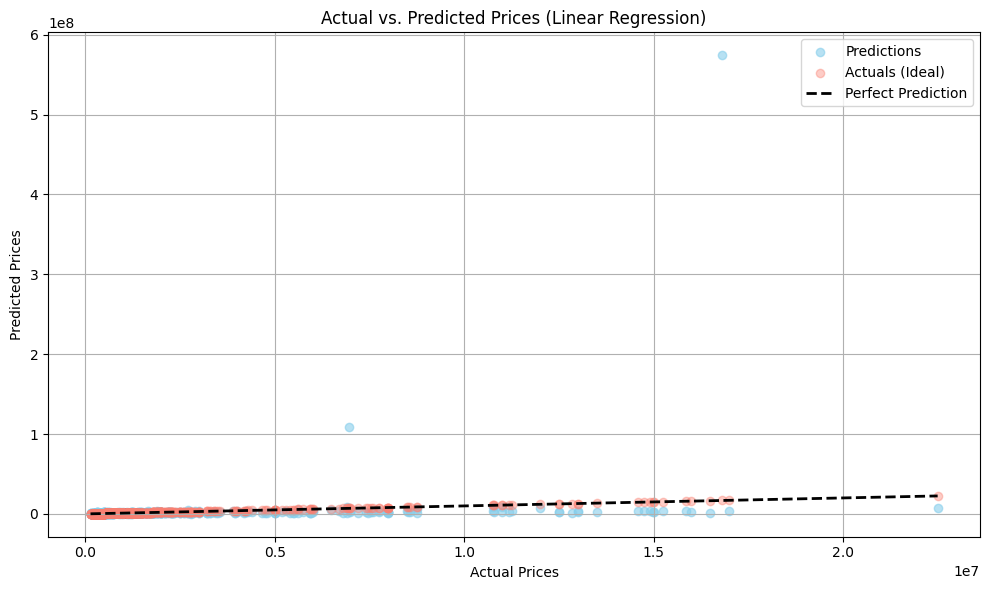


Ridge Regression RMSE (Original Scale): 18482892.03919457


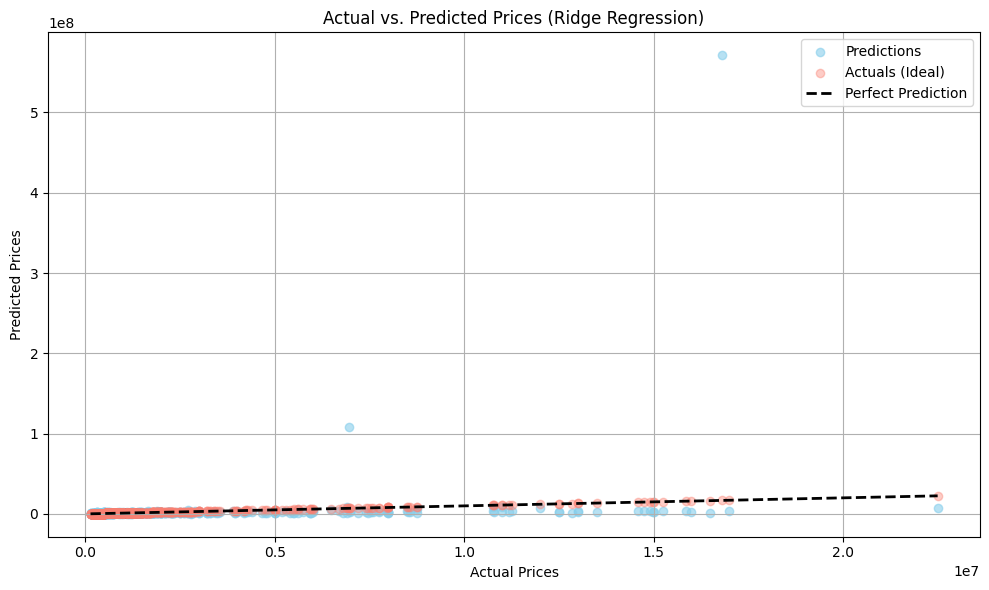


Random Forest Regressor RMSE (Original Scale): 1226552.1896884395


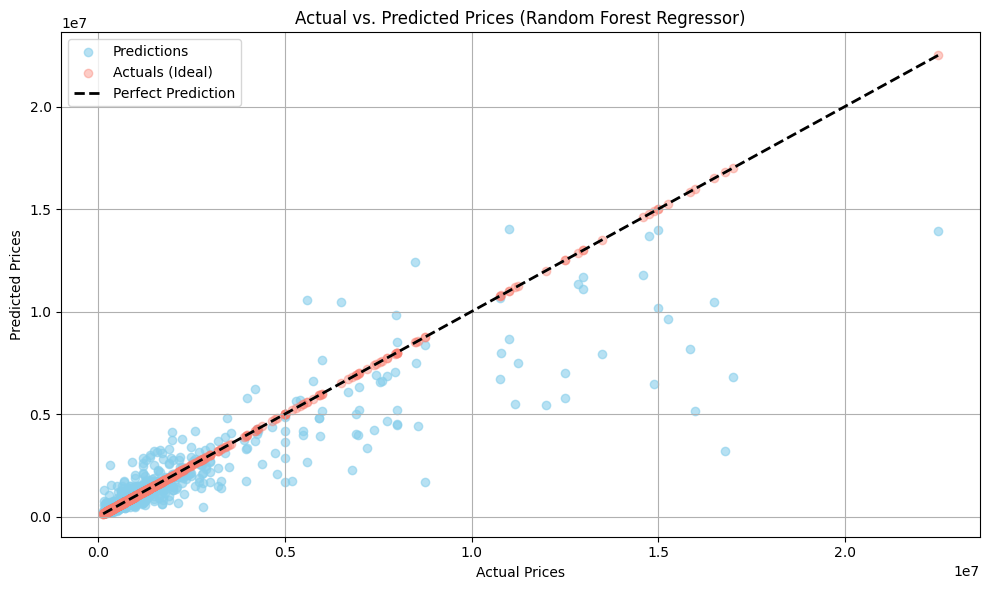


Gradient Boosting Regressor RMSE (Original Scale): 1274648.6046858022


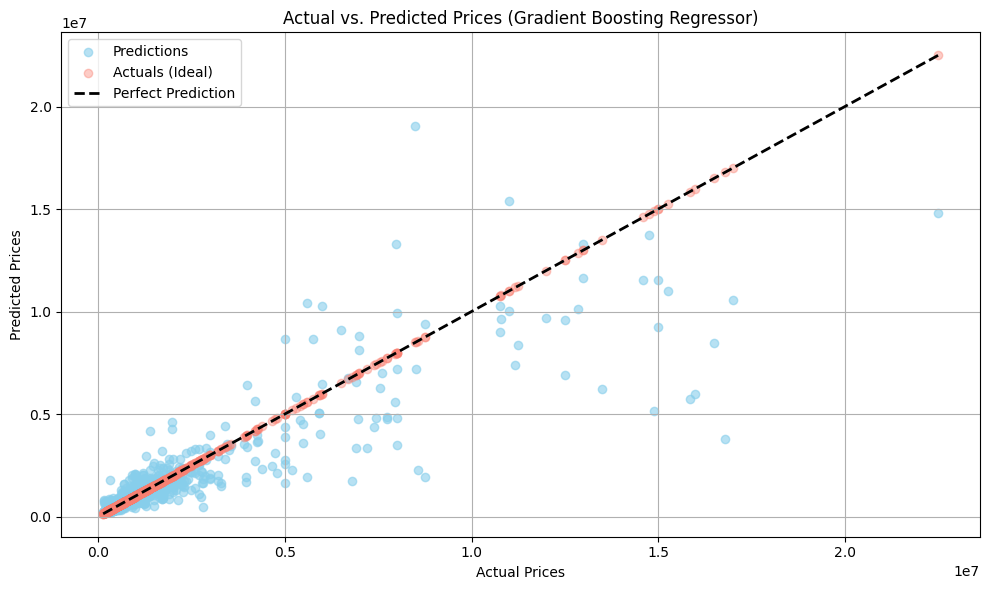


--- Feature Importances (Random Forest) ---
BATH                        0.349963
PROPERTYSQFT                0.172976
LONGITUDE                   0.133806
LATITUDE                    0.119407
LOCALITY_New York County    0.062898
BEDS_BATHS                  0.041383
SQFT_BEDS                   0.037237
SQFT_BATH                   0.021340
TYPE_Co-op for sale         0.017557
TYPE_Townhouse for sale     0.007792
dtype: float64

--- Further Iteration Ideas ---
- More sophisticated feature engineering from ADDRESS and location data (e.g., using geocoding to get neighborhood features).
- Using external datasets for neighborhood desirability, school ratings, crime rates, or economic indicators.
- More careful analysis and handling of remaining outliers in numerical features (e.g., PROPERTYSQFT).
- Trying more advanced models and hyperparameter tuning techniques (e.g., XGBoost, LightGBM, Bayesian optimization).
- Exploring different encoding techniques for high-cardinality categorical variab

In [21]:
evaluate_model(y_val, y_pred_lr_log, "Linear Regression")
evaluate_model(y_val, y_pred_ridge_log, "Ridge Regression")
evaluate_model(y_val, y_pred_rf_log, "Random Forest Regressor")
evaluate_model(y_val, y_pred_gb_log, "Gradient Boosting Regressor")

# --- Feature Importance (Example for Random Forest) ---
best_rf_model_preprocessor = best_rf_model.named_steps['preprocessor']
best_rf_model_regressor = best_rf_model.named_steps['regressor']

feature_names = numerical_features_for_scaling + list(best_rf_model_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

if isinstance(best_rf_model_regressor, RandomForestRegressor):
    importances = best_rf_model_regressor.feature_importances_
    feature_importances = pd.Series(importances, index=feature_names)
    feature_importances_sorted = feature_importances.sort_values(ascending=False)
    print("\n--- Feature Importances (Random Forest) ---")
    print(feature_importances_sorted.head(10))

# --- Further Iteration Ideas ---
print("\n--- Further Iteration Ideas ---")
print("- More sophisticated feature engineering from ADDRESS and location data (e.g., using geocoding to get neighborhood features).")
print("- Using external datasets for neighborhood desirability, school ratings, crime rates, or economic indicators.")
print("- More careful analysis and handling of remaining outliers in numerical features (e.g., PROPERTYSQFT).")
print("- Trying more advanced models and hyperparameter tuning techniques (e.g., XGBoost, LightGBM, Bayesian optimization).")
print("- Exploring different encoding techniques for high-cardinality categorical variables (e.g., target encoding).")
print("- Analyzing and potentially modeling different price segments separately.")
print("- Investigating polynomial features or interaction terms for numerical features.")

### Conclusion of Model Evaluation:

Based on the calculated RMSE values on the validation dataset, the Random Forest Regressor demonstrated the lowest prediction error of approximately $\$$1,226,552 (original scale), outperforming the Linear Regression ($\$$18,583,888), Ridge Regression ($\$$18,482,892), and Gradient Boosting Regressor ($\$$1,274,649) models in this initial evaluation. While the Random Forest shows the most promise, the substantial RMSE across all models underscores the inherent complexity of accurately predicting real estate prices in a diverse market like New York City. This suggests that further refinements and more sophisticated techniques are necessary to achieve higher prediction accuracy.

The generated scatter plots visually reinforce these findings. Ideally, the blue prediction points should closely align with the dashed black line representing perfect predictions. Deviations from this line indicate prediction errors. While the Random Forest Regressor's predictions appear visually closer to the ideal line compared to the other models, there's still a noticeable spread, particularly for higher-priced properties.
$\$$3,080,532.18

### Further Avenues for Improvement:
As highlighted by the evaluation results, achieving higher prediction accuracy in this domain likely necessitates significant effort in feature engineering and potentially the incorporation of external data sources. The following are some potential areas for future exploration and improvement, building upon the initial ideas:

* **Enhanced Location Feature Engineering:**
    * **Geocoding:** Utilize the `ADDRESS` information and geocoding services (e.g., via APIs) to extract more granular location features such as specific neighborhood names, borough, zip codes, and potentially even community district information.
    * **Proximity to Amenities:** Calculate distances to key amenities like subway stations, parks, schools, hospitals, and commercial centers using external geospatial data and libraries like `geopy` or specialized APIs. These factors significantly influence property values in urban environments.
<br><br>


* **Incorporating External Datasets:**
    * **Neighborhood Desirability Metrics:** Integrate data related to neighborhood quality of life, safety (crime rates), school ratings, and access to public transportation.
    * **Economic Indicators:** Include macroeconomic factors like unemployment rates, interest rates, and housing market indices for the NYC metropolitan area.
<br><br>

* **Advanced Outlier Management:**
    * **Robust Scaling:** Explore scaling techniques that are less sensitive to outliers, such as RobustScaler.
    * **Winsorization:** Cap extreme values at a certain percentile to reduce their impact without completely removing them.
    * **Separate Modeling:** Consider building separate models for different price segments (e.g., low, medium, high) if the drivers of price differ significantly across these ranges.
<br><br>


* **Advanced Modeling Techniques and Hyperparameter Tuning:**
    * **More Sophisticated Models:** Experiment with other advanced regression models like Support Vector Regression (SVR) or neural networks.
    * **Bayesian Optimization:** Employ more efficient hyperparameter tuning methods like Bayesian optimization (e.g., using libraries like Optuna or Hyperopt) which can often find better hyperparameter combinations with fewer evaluations than grid search.
    * **Ensemble Methods:** Explore more advanced ensemble techniques like stacking or blending multiple well-performing models.
<br><br>


* **Improved Categorical Feature Encoding:**
    * **Target Encoding:** For high-cardinality categorical features (if any emerge from more detailed address parsing), consider target encoding techniques where categories are replaced by the mean or median of the target variable for that category. However, be cautious of potential overfitting with this method.
    * **Embedding Techniques:** For very high-cardinality categorical features, explore embedding techniques similar to those used in natural language processing.
<br><br>


* **Targeted Analysis of High-Priced Properties:** Specifically investigate the characteristics of very expensive properties to understand the factors driving their high values and ensure the model adequately accounts for them. This might involve more detailed qualitative analysis in conjunction with quantitative modeling.

## General Conclusion and Recommendations for Stakeholders

In essence, this project represents an initial yet crucial step towards building a data-driven tool for predicting property prices in New York City using machine learning. We have successfully explored the available data, engineered relevant features, and tested several fundamental prediction methods, including linear models and more sophisticated ensemble techniques. Our findings indicate that while models like Gradient Boosting and Random Forest show promise with lower RMSE values compared to linear models, accurately predicting housing prices in a complex market like NYC remains a significant challenge. The substantial RMSE across all models underscores the influence of numerous uncaptured factors and the inherent variability in real estate valuations.

### Recommendations for Stakeholders:
1. **Acknowledge Model Limitations:** Understand that the current best model (Random Forest) provides estimates with an average error of approximately $1.23 million. These predictions should be used as a guide and not as definitive valuations.<br><br>
2. **Invest in Enhanced Data Collection and Feature Engineering:** Future efforts should prioritize enriching the dataset with more detailed location information (e.g., neighborhood), proximity to key amenities, and potentially external data sources related to neighborhood quality and economic indicators. More sophisticated feature engineering techniques, especially for location-based data, are likely to yield significant improvements.<br><br>
3. **Explore Advanced Modeling Techniques:** Consider further experimentation with more advanced machine learning models and hyperparameter tuning strategies to potentially capture more complex, non-linear relationships within the data.<br><br>
4. **Focus on Specific Market Segments:** Given the wide range of property prices in NYC, it might be beneficial to develop separate predictive models for different market segments (e.g., luxury apartments, co-ops, single-family homes in specific boroughs) as the key price drivers might vary.<br><br>
5. **Continuous Monitoring and Refinement:** The real estate market is dynamic. The models should be continuously monitored for performance degradation and retrained with new data to maintain their predictive accuracy over time.

This project provides a solid foundation for further development. By addressing the identified limitations and pursuing the suggested avenues for improvement, the potential for building a more accurate and reliable housing price prediction tool for New York City can be significantly enhanced.

